# ESPAC Flow Diagram

This notebook renders an annotated flow diagram of the ESPAC project directly in Jupyter using Matplotlib patches and arrows.

It reflects the current notebook-driven workflow documented in this repository:

- Step 1: ETL from raw ESPAC delivery to SQLite
- Step 2: LCI extraction and aggregation
- Step 3: direct field emissions
- Step 4: exchange-table roundtrip and process matching
- Step 5: XML generation and diagnostics


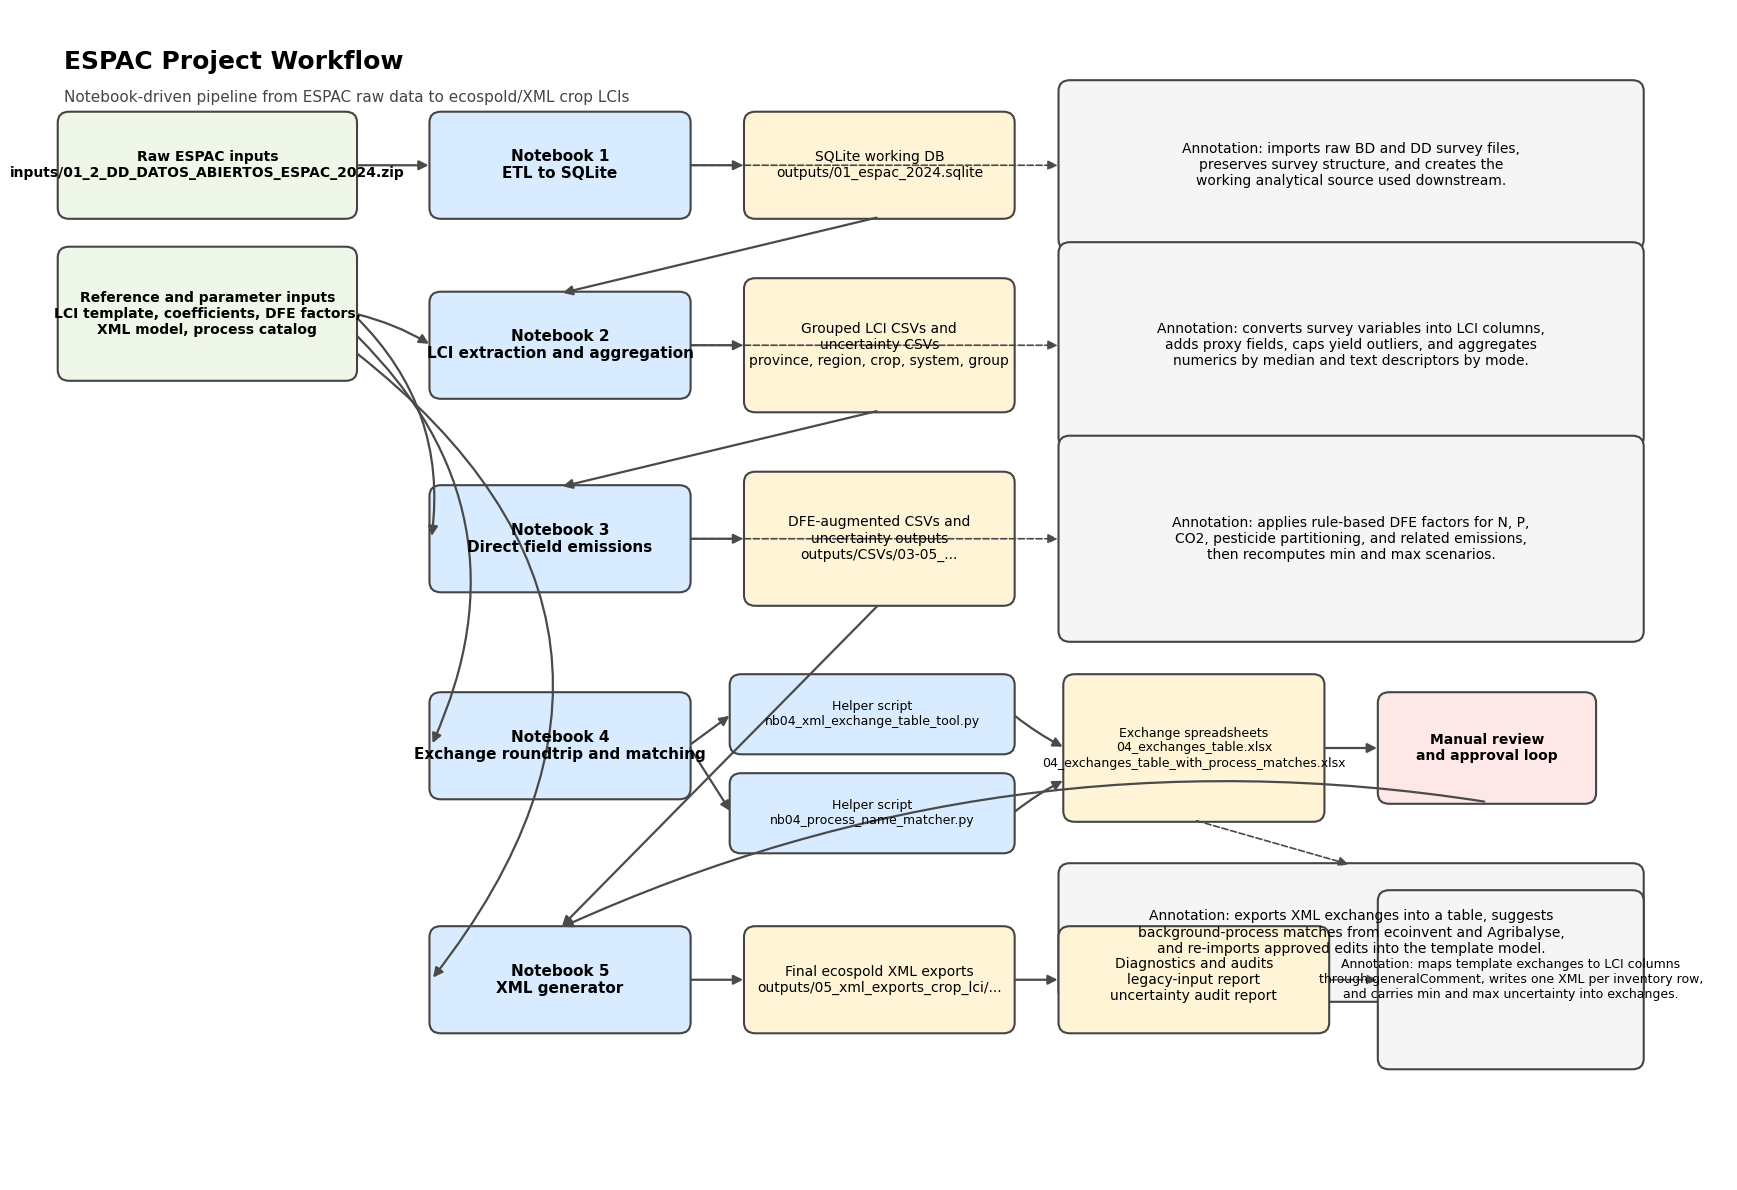

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 13)
ax.axis('off')

COLORS = {
    'stage': '#d9ecff',
    'data': '#eef7e8',
    'output': '#fff4d6',
    'manual': '#fde7e7',
    'note': '#f5f5f5',
    'edge': '#4a4a4a',
}

def box(x, y, w, h, text, fc, ec='#444444', size=10, weight='normal', radius=0.12):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f'round,pad=0.02,rounding_size={radius}',
        linewidth=1.5,
        facecolor=fc,
        edgecolor=ec,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=size, weight=weight, wrap=True)
    return {'x': x, 'y': y, 'w': w, 'h': h}

def center_right(b):
    return (b['x'] + b['w'], b['y'] + b['h'] / 2)

def center_left(b):
    return (b['x'], b['y'] + b['h'] / 2)

def center_top(b):
    return (b['x'] + b['w'] / 2, b['y'] + b['h'])

def center_bottom(b):
    return (b['x'] + b['w'] / 2, b['y'])

def arrow(p1, p2, style='-|>', ls='-', color=COLORS['edge'], lw=1.6, rad=0.0):
    patch = FancyArrowPatch(
        p1, p2,
        arrowstyle=style,
        mutation_scale=14,
        linewidth=lw,
        linestyle=ls,
        color=color,
        connectionstyle=f'arc3,rad={rad}',
    )
    ax.add_patch(patch)

def routed_arrow(points, style='-|>', ls='-', color=COLORS['edge'], lw=1.6):
    xs, ys = zip(*points)
    ax.plot(xs[:-1], ys[:-1], linestyle=ls, linewidth=lw, color=color, solid_capstyle='round', dash_capstyle='round')
    arrow(points[-2], points[-1], style=style, ls=ls, color=color, lw=lw)

raw = box(0.5, 10.7, 3.1, 1.15, 'Raw ESPAC inputs\ninputs/01_2_DD_DATOS_ABIERTOS_ESPAC_2024.zip', COLORS['data'], size=10, weight='bold')
refs = box(0.5, 8.9, 3.1, 1.45, 'Reference and parameter inputs\nLCI template, coefficients, DFE factors,\nXML model, process catalog', COLORS['data'], size=10, weight='bold')

n1 = box(4.4, 10.7, 2.7, 1.15, 'Notebook 1\nETL to SQLite', COLORS['stage'], size=11, weight='bold')
o1 = box(7.7, 10.7, 2.8, 1.15, 'SQLite working DB\noutputs/01_espac_2024.sqlite', COLORS['output'], size=10)
a1 = box(11.0, 10.35, 6.1, 1.85, 'Annotation: imports raw BD and DD survey files,\npreserves survey structure, and creates the\nworking analytical source used downstream.', COLORS['note'], size=10)

n2 = box(4.4, 8.7, 2.7, 1.15, 'Notebook 2\nLCI extraction and aggregation', COLORS['stage'], size=11, weight='bold')
o2 = box(7.7, 8.55, 2.8, 1.45, 'Grouped LCI CSVs and\nuncertainty CSVs\nprovince, region, crop, system, group', COLORS['output'], size=10)
a2 = box(11.0, 8.15, 6.1, 2.25, 'Annotation: converts survey variables into LCI columns,\nadds proxy fields, caps yield outliers, and aggregates\nnumerics by median and text descriptors by mode.', COLORS['note'], size=10)

n3 = box(4.4, 6.55, 2.7, 1.15, 'Notebook 3\nDirect field emissions', COLORS['stage'], size=11, weight='bold')
o3 = box(7.7, 6.4, 2.8, 1.45, 'DFE-augmented CSVs and\nuncertainty outputs\noutputs/CSVs/03-05_...', COLORS['output'], size=10)
a3 = box(11.0, 6.0, 6.1, 2.25, 'Annotation: applies rule-based DFE factors for N, P,\nCO2, pesticide partitioning, and related emissions,\nthen recomputes min and max scenarios.', COLORS['note'], size=10)

n4 = box(4.4, 4.25, 2.7, 1.15, 'Notebook 4\nExchange roundtrip and matching', COLORS['stage'], size=11, weight='bold')
s1 = box(7.55, 4.75, 2.95, 0.85, 'Helper script\nnb04_xml_exchange_table_tool.py', COLORS['stage'], size=9)
s2 = box(7.55, 3.65, 2.95, 0.85, 'Helper script\nnb04_process_name_matcher.py', COLORS['stage'], size=9)
o4 = box(11.05, 4.0, 2.7, 1.6, 'Exchange spreadsheets\n04_exchanges_table.xlsx\n04_exchanges_table_with_process_matches.xlsx', COLORS['output'], size=9)
m1 = box(14.35, 4.2, 2.25, 1.2, 'Manual review\nand approval loop', COLORS['manual'], size=10, weight='bold')
a4 = box(10.95, 2.2, 5.95, 1.1, 'Annotation: exports XML exchanges into a table, suggests\nbackground-process matches from ecoinvent and Agribalyse,\nand re-imports approved edits into the template model.', COLORS['note'], size=9.2)

n5 = box(4.4, 0.75, 2.7, 1.15, 'Notebook 5\nXML generator', COLORS['stage'], size=11, weight='bold')
o5 = box(7.7, 0.75, 2.8, 1.15, 'Final ecospold XML exports\noutputs/05_xml_exports_crop_lci/...', COLORS['output'], size=10)
r1 = box(10.95, 0.75, 2.9, 1.15, 'Diagnostics and audits\nlegacy-input report\nuncertainty audit report', COLORS['output'], size=10)
a5 = box(14.25, 0.25, 2.85, 1.2, 'Annotation: maps template exchanges to LCI columns\nthrough generalComment, writes one XML per inventory row,\nand carries uncertainty into exchanges.', COLORS['note'], size=8.2)

arrow(center_right(raw), center_left(n1))
arrow(center_right(n1), center_left(o1))
routed_arrow([center_bottom(o1), (9.1, 10.3), (5.75, 10.3), center_top(n2)])
routed_arrow([center_right(refs), (4.0, 9.625), (4.0, 9.275), center_left(n2)])
arrow(center_right(n2), center_left(o2))
routed_arrow([center_bottom(o2), (9.1, 8.2), (5.75, 8.2), center_top(n3)])
routed_arrow([center_bottom(refs), (2.05, 8.55), (2.05, 7.125), center_left(n3)])
arrow(center_right(n3), center_left(o3))

routed_arrow([center_bottom(refs), (2.35, 8.35), (2.35, 4.825), center_left(n4)])
arrow(center_right(n4), center_left(s1))
arrow(center_right(n4), center_left(s2))
routed_arrow([center_right(s1), (10.8, 5.175), center_left(o4)])
routed_arrow([center_right(s2), (10.8, 4.075), (10.8, 4.45), (11.05, 4.45)])
arrow(center_right(o4), center_left(m1))
routed_arrow([center_bottom(m1), (15.475, 3.6), (5.75, 3.6), center_top(n5)])

routed_arrow([center_bottom(o3), (9.1, 2.35), (5.75, 2.35), center_top(n5)])
routed_arrow([center_bottom(refs), (2.65, 8.15), (2.65, 1.325), center_left(n5)])
arrow(center_right(n5), center_left(o5))
arrow(center_right(o5), center_left(r1))

arrow(center_right(n1), center_left(a1), ls='--', lw=1.2)
arrow(center_right(n2), center_left(a2), ls='--', lw=1.2)
arrow(center_right(n3), center_left(a3), ls='--', lw=1.2)
routed_arrow([center_bottom(o4), (12.4, 3.75), (12.4, 3.3), center_top(a4)], ls='--', lw=1.2)
routed_arrow([center_right(r1), (14.05, 1.325), (14.05, 0.85), center_left(a5)], ls='--', lw=1.2)

ax.text(0.55, 12.35, 'ESPAC Project Workflow', fontsize=18, weight='bold', ha='left')
ax.text(0.55, 11.98, 'Notebook-driven pipeline from ESPAC raw data to ecospold/XML crop LCIs', fontsize=11, ha='left', color='#444444')

plt.tight_layout()
fig.savefig('ESPAC_flow_diagram.png', dpi=200, bbox_inches='tight')
fig.savefig('ESPAC_flow_diagram.svg', bbox_inches='tight')
plt.show()
